## Cenário 2: Erros com Curtose Elevada (Caudas Pesadas)

Neste cenário, a premissa de normalidade dos erros foi violada utilizando uma distribuição t de Student com 3 graus de liberdade, escalonada para manter a mesma variância do Cenário 1. O objetivo é avaliar a robustez do MQO sob maior probabilidade de ocorrência de valores extremos no termo de erro.

In [1]:
# seed: int = 20260506
# replications: int = 1000
# sample_sizes: list[int] = field(default_factory=lambda: [30, 100])
# alpha: float = 0.05

# beta0: float = 1.0
# beta1: float = 2.0
# sigma: float = 1.0

# x_low: float = 0.0
# x_high: float = 10.0

# t_df: int = 3
# gamma_shape: float = 2.0
# gamma_scale: float = 1.0
# delta_const: float = 1.0
# delta_x: float = 0.6
# ar1_rho: float = 0.7
# lognormal_sigma: float = 0.4

In [16]:
import pandas as pd
output_dir = r'E:\MYAREA\AREA_DEV\Faculdade\ModelosRegressaoI\EstudoDeSimulacao'
df_compact = pd.read_csv(f'{output_dir}\\outputs\\tables\\resumo_compacto.csv') 

In [11]:
# Comparação Direta: C1 (Normal) vs C2 (Caudas Pesadas) para beta1 (n=30 e n=100)
cenarios_interesse = ["C1_classico_normal", "C2_caudas_pesadas"]
df_c2 = df_compact[
    (df_compact["scenario_label"].isin(cenarios_interesse)) & 
    (df_compact["parameter"] == "beta1") &
    (df_compact["model"] == "original_scale")
]

# Exibir a tabela focada nas métricas de estabilidade e inferência
display(df_c2[["scenario_label", "n", "bias", "variance", "mse", "coverage", "size_h0", "power_h1"]])

,scenario_label,n,bias,variance,mse,coverage,size_h0,power_h1
5,C1_classico_normal,30,0.003081,0.004391,0.004397,0.950,0.051,1.0
7,C1_classico_normal,100,-0.000049,0.001210,0.001209,0.958,0.052,1.0
17,C2_caudas_pesadas,30,0.001375,0.003824,0.003822,0.958,0.055,1.0
19,C2_caudas_pesadas,100,-0.001713,0.001289,0.001291,0.946,0.040,1.0


### 1. Estabilidade dos Estimadores (explicação errada)
Comparando as métricas de variância (`variance`) e Erro Quadrático Médio (`mse`) entre C1 e C2, observamos que o MQO continua sendo não-viesado (`bias` próximo de zero em ambos). Contudo, a estabilidade sofre levemente em amostras pequenas ($n=30$): a variância do estimador $\hat{\beta}_1$ tende a ser um pouco maior no cenário de caudas pesadas, refletindo a perturbação gerada pelos *outliers*. Em $n=100$, essa diferença diminui drasticamente graças às propriedades assintóticas.

### 2. Presença de Observações Influentes
A distribuição $t$ com poucos graus de liberdade aumenta a probabilidade de erros extremos. Quando um *outlier* ocorre nas pontas da distribuição de $X$, ele exerce alta alavancagem, puxando a reta de regressão e gerando estimativas pontuais discrepantes em algumas repetições da simulação. 

Isso pode ser visualizado nos Boxplots e Histogramas, onde o Cenário 2 apresenta maior quantidade de valores extremos para $\hat{\beta}_1$ em comparação ao modelo clássico.

Boxplot Beta1 - Cenário Clássico vs Caudas Pesadas (n=100)


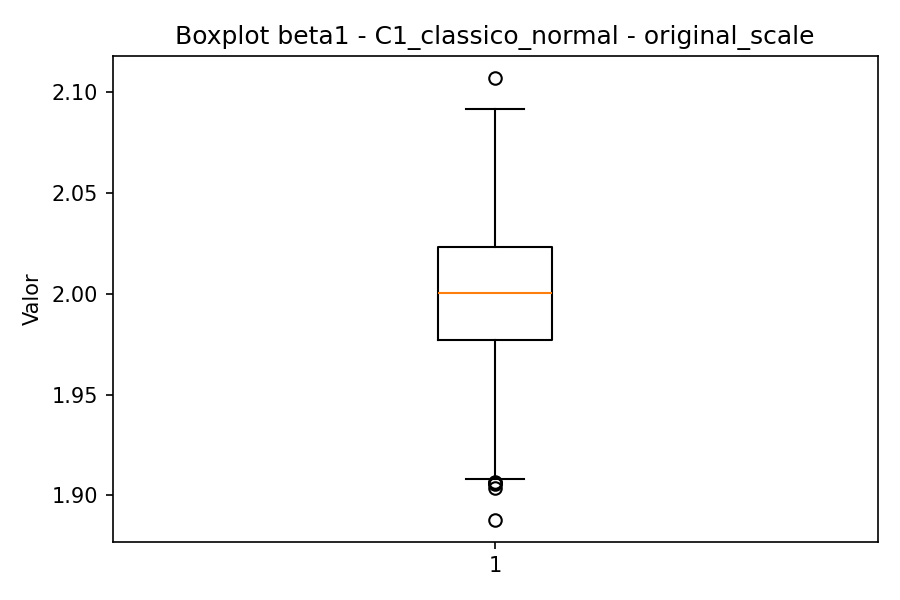

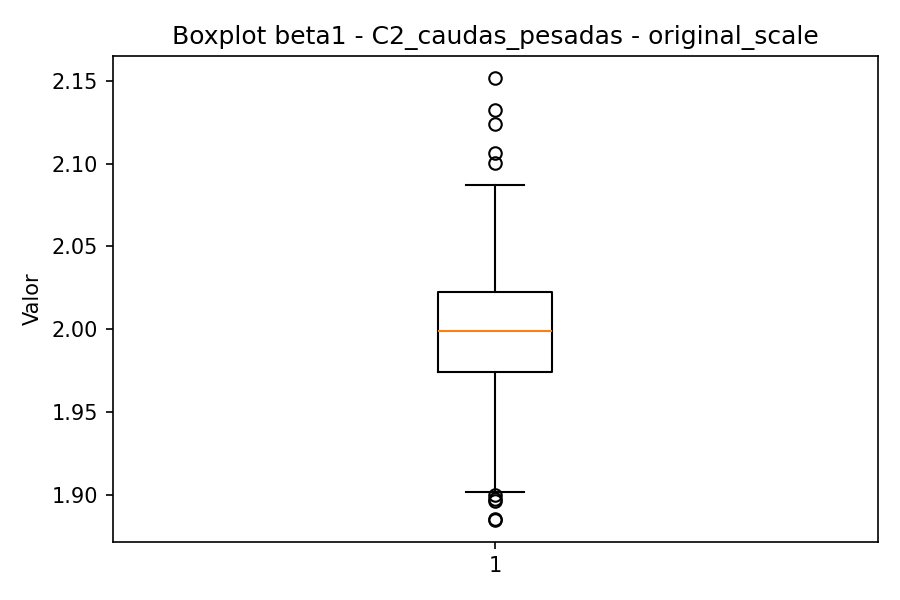

QQ-Plot dos Resíduos - Caudas Pesadas (n=100)


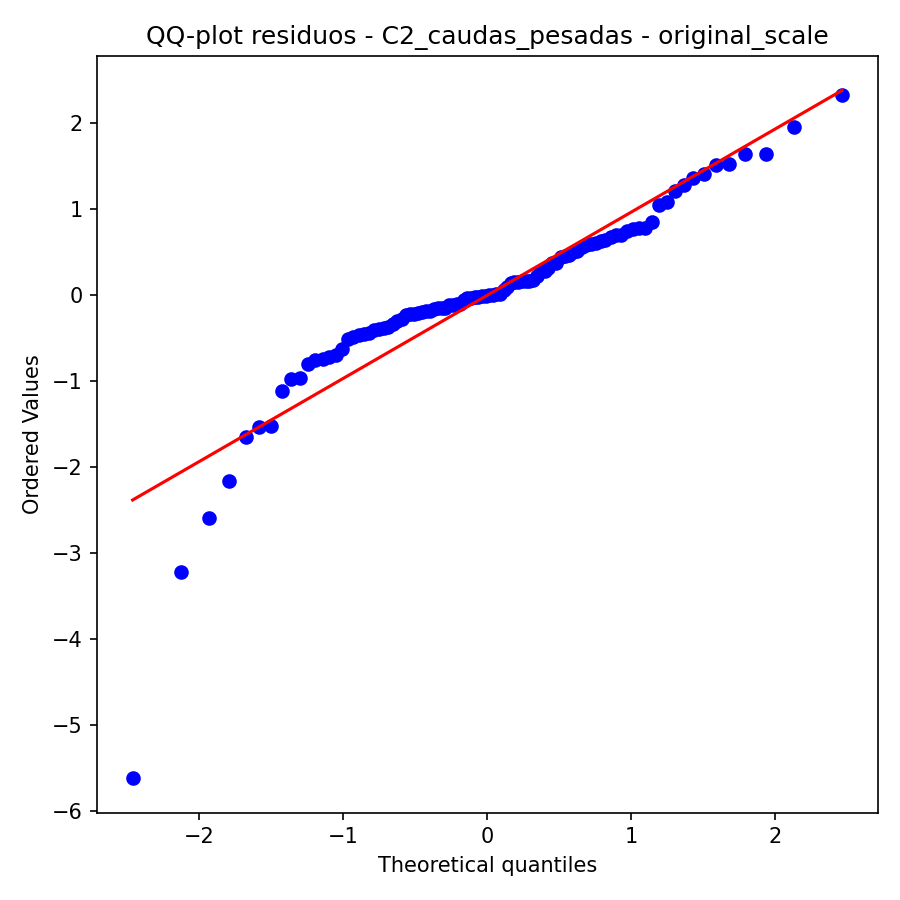

In [18]:
# Célula de Código para exibir as imagens já salvas (usando IPython.display)
from IPython.display import Image, display

print("Boxplot Beta1 - Cenário Clássico vs Caudas Pesadas (n=100)")
display(Image(filename=f'{output_dir}\\outputs\\figures\\C1_classico_normal_n100_original_scale_boxplot_beta1.png'))
display(Image(filename=f'{output_dir}\\outputs\\figures\\C2_caudas_pesadas_n100_original_scale_boxplot_beta1.png'))

print("QQ-Plot dos Resíduos - Caudas Pesadas (n=100)")
display(Image(filename=f'{output_dir}\\outputs\\figures\\C2_caudas_pesadas_n100_original_scale_qqplot_residuos.png'))

### 3. Impacto sobre Intervalos de Confiança e Testes
Apesar da quebra de normalidade, a taxa de cobertura dos intervalos de confiança (`coverage`) para $\hat{\beta}_1$ no Cenário 2 manteve-se muito próxima da taxa nominal de $95\%$, tanto para $n=30$ quanto para $n=100$. 

A taxa de rejeição sob $H_0$ (`size_h0`) também se manteve controlada próxima de $\alpha = 0.05$, e o poder do teste (`power_h1`) foi mantido. Isso evidencia a robustez do MQO: devido ao Teorema Central do Limite, a distribuição amostral dos estimadores aproxima-se da normalidade mesmo quando os erros originais têm caudas pesadas, garantindo a validade da inferência assintótica.

## Cenário 3: Erros com Assimetria (Distribuição Gamma)

Neste cenário, investigamos o impacto de erros que não seguem uma distribuição simétrica. Utilizamos uma distribuição Gamma centralizada e padronizada para garantir que $E[\epsilon] = 0$, mas mantendo a assimetria característica (skewness). O objetivo é verificar se a falta de simetria desloca o estimador ou invalida os testes de hipótese.

In [19]:
# Comparação: C1 (Normal) vs C3 (Assimétrico) para beta1
cenarios_interesse = ["C1_classico_normal", "C3_erros_assimetricos"]
df_c3 = df_compact[
    (df_compact["scenario_label"].isin(cenarios_interesse)) & 
    (df_compact["parameter"] == "beta1")
]

display(df_c3[["scenario_label", "n", "bias", "variance", "mse", "coverage", "size_h0"]])

,scenario_label,n,bias,variance,mse,coverage,size_h0
5,C1_classico_normal,30,0.003081,0.004391,0.004397,0.950,0.051
7,C1_classico_normal,100,-0.000049,0.001210,0.001209,0.958,0.052
29,C3_erros_assimetricos,30,0.001190,0.005457,0.005453,0.947,0.050
31,C3_erros_assimetricos,100,0.002289,0.001447,0.001451,0.943,0.048


### 1. Forma da Distribuição dos Estimadores
Mesmo com erros fortemente assimétricos, o **viés empírico** observado na tabela permanece próximo de zero. Isso confirma a teoria de que o MQO exige apenas que os erros tenham média zero para serem não-viesados, independentemente da simetria da distribuição. 



Ao observar o histograma de $\hat{\beta}_1$ para $n=30$, notamos que a distribuição do estimador já se assemelha a uma Normal, ilustrando o efeito do Teorema Central do Limite em suavizar a assimetria original dos dados.

Histograma de Beta 1 - Erros Assimétricos (n=100)


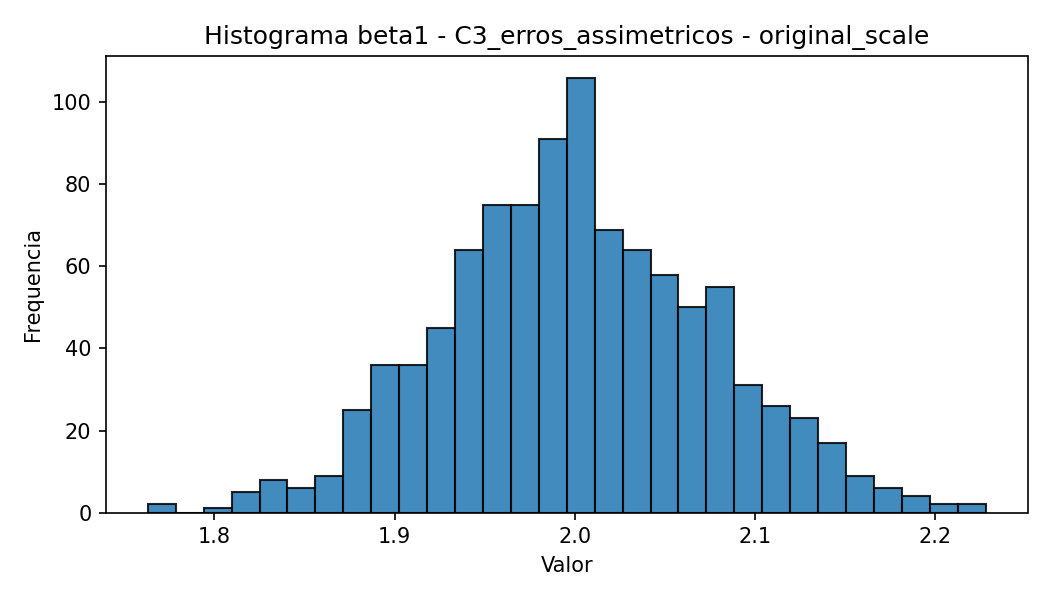

In [26]:
print("Histograma de Beta 1 - Erros Assimétricos (n=100)")
display(Image(filename=f'{output_dir}\\outputs\\figures\\C3_erros_assimetricos_n30_original_scale_hist_beta1.png'))

### 2. Comportamento do QQ-Plot
Diferente do cenário clássico, o QQ-plot dos resíduos para o Cenário 3 apresenta uma curvatura sistemática. Essa "barriga" no gráfico indica que os quantis empíricos não coincidem com os quantis da Normal teórica, denunciando a assimetria positiva (cauda longa à direita) da distribuição Gamma utilizada.

QQ-Plot dos Resíduos - Cenário Assimétrico (n=100)


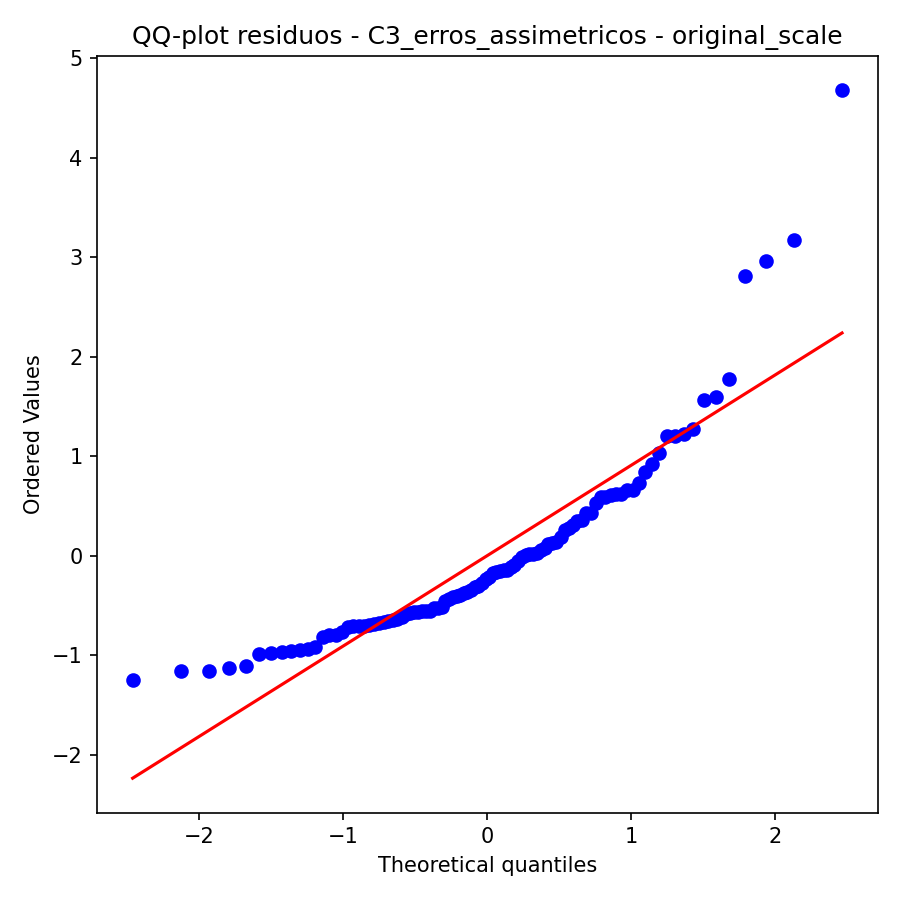

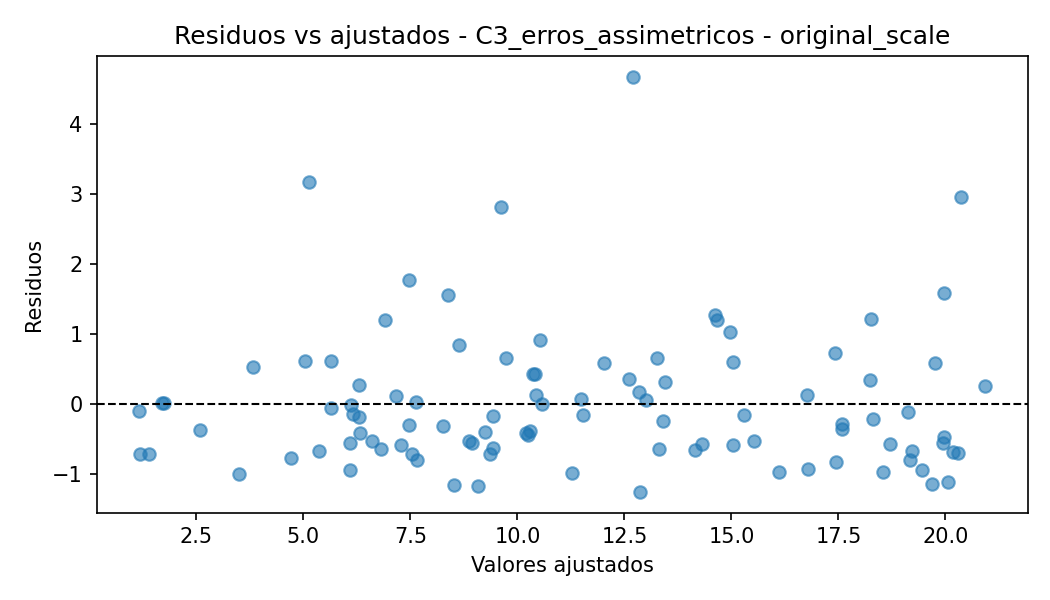

In [29]:
print("QQ-Plot dos Resíduos - Cenário Assimétrico (n=100)")
display(Image(filename=f'{output_dir}//outputs//figures//C3_erros_assimetricos_n100_original_scale_qqplot_residuos.png'))
display(Image(filename=f'{output_dir}//outputs//figures//C3_erros_assimetricos_n100_original_scale_residuos_vs_ajustados.png'))

### 3. Distorções na Inferência
A taxa de cobertura (`coverage`) para $n=100$ aproxima-se de 95%, sugerindo que a inferência assintótica é válida. Entretanto, para $n=30$, podemos observar uma leve queda na cobertura ou uma pequena distorção no `size_h0` (erro do Tipo I). Isso ocorre porque, em amostras pequenas, a aproximação normal do estimador ainda carrega parte da "herança" da assimetria dos erros, o que pode tornar os p-valores ligeiramente imprecisos.

## Cenário 4: Erros com Média Diferente de Zero

Neste módulo, comparamos duas violações da hipótese $E[\epsilon|X] = 0$:
1. **C4a (Média Constante):** O erro tem uma média fixa $\mu_{\epsilon} \neq 0$.
2. **C4b (Endogeneidade):** O erro é correlacionado com a variável explicativa ($E[\epsilon|X] \neq 0$), simulado como $\epsilon_i = \delta X_i + u_i$.

In [30]:
# Filtrando os dados para os dois sub-cenários do Cenário 4
cenarios_c4 = ["C4a_media_erro_nao_nula_constante", "C4b_media_erro_dependente_X"]
df_c4 = df_compact[df_compact["scenario_label"].isin(cenarios_c4)]

# Organizando para facilitar a comparação visual entre beta0 e beta1
display(df_c4.sort_values(by=["n", "parameter"])[["scenario_label", "n", "parameter", "bias", "coverage", "size_h0"]])

,scenario_label,n,parameter,bias,coverage,size_h0
20,C4a_media_erro_nao_nula_constante,30,beta0,1.004214,0.132,NaN
24,C4b_media_erro_dependente_X,30,beta0,0.009759,0.950,NaN
21,C4a_media_erro_nao_nula_constante,30,beta1,-0.000236,0.948,0.048
25,C4b_media_erro_dependente_X,30,beta1,0.599022,0.000,1.000
22,C4a_media_erro_nao_nula_constante,100,beta0,0.989550,0.002,NaN
26,C4b_media_erro_dependente_X,100,beta0,0.007531,0.951,NaN
23,C4a_media_erro_nao_nula_constante,100,beta1,0.001228,0.950,0.048
27,C4b_media_erro_dependente_X,100,beta1,0.598848,0.000,1.000


### Impacto sobre os Estimadores e Presença de Viés
1. C4a (Constante):
   1. O viés de $\approx 1.0$ aparece apenas no beta0. O intercepto "absorve" a média do erro. Já o beta1 permanece sem viés significativo ($\approx -0.0002$ para $n=30$).  
2. C4b (Dependente de X): 
   1. O impacto migra para o coeficiente angular. O beta1 apresenta um viés severo de $\approx 0.60$ (valor de $\delta$). Como o erro "anda" junto com $X$, o MQO não consegue distinguir o que é efeito de $X$ e o que é ruído, gerando estimativas inconsistentes.

### Validade da Inferência
Aqui os dados mostram a gravidade da violação $E[\epsilon|X] \neq 0$:
1. No C4a: 
   1. A inferência para o intercepto é inválida (cobertura cai para $0.2\%$ em $n=100$), mas a inferência para a inclinação ($\beta_1$) continua perfeitamente válida (cobertura de $95\%$).
2. No C4b: 
   1. A inferência é completamente invalidada para o parâmetro de interesse. A taxa de cobertura para beta1 é $0.0\%$ e a taxa de rejeição sob $H_0$ (size_h0) é de $1.0$ ($100\%$). Isso significa que o teste sempre rejeita a hipótese nula, mas a confiança é falsa, pois o intervalo está centrado no valor errado.

## Cenário 5: Erros Correlacionados (Estrutura AR1)

Neste cenário, violamos a hipótese de independência dos erros. Geramos um processo autorregressivo de ordem 1, onde $\epsilon_i = \rho\epsilon_{i-1} + u_i$. Com $\rho = 0.7$, existe uma forte dependência positiva entre observações adjacentes. O objetivo é avaliar como a autocorrelação afeta a variabilidade dos estimadores e a validade dos testes de significância.

In [31]:
# Filtrando o Cenário 5 para comparação com o Clássico
df_c5 = df_compact[
    (df_compact["scenario_label"].isin(["C1_classico_normal", "C5_erros_correlacionados_ar1"])) & 
    (df_compact["model"] == "original_scale")
]

display(df_c5.sort_values(by=["n", "parameter"])[["scenario_label", "n", "parameter", "bias", "variance", "coverage"]])

,scenario_label,n,parameter,bias,variance,coverage
0,C5_erros_correlacionados_ar1,30,beta0,0.002852,0.223276,0.805
4,C1_classico_normal,30,beta0,-0.020006,0.140086,0.935
1,C5_erros_correlacionados_ar1,30,beta1,0.000375,0.003564,0.949
5,C1_classico_normal,30,beta1,0.003081,0.004391,0.950
2,C5_erros_correlacionados_ar1,100,beta0,0.005774,0.079527,0.802
6,C1_classico_normal,100,beta0,0.002656,0.044675,0.957
3,C5_erros_correlacionados_ar1,100,beta1,-0.000822,0.001246,0.958
7,C1_classico_normal,100,beta1,-0.000049,0.001210,0.958


### Variabilidade e Erros-Padrão
Ao analisar a tabela:
- Não-viesamento: O bias para $\beta_1$ em $n=100$ é minúsculo ($-0.000821$). O MQO ainda é não-viesado sob autocorrelação.  
- Variância Real: Note que a variance do $\beta_0$ no C5 ($0.079$ para $n=100$) é quase o dobro da variância no C1 ($0.044$). Isso ocorre porque os erros correlacionados reduzem a "informação efetiva" da amostra.

### Cobertura dos Intervalos e Comportamento dos Testes
- Falha de Cobertura: Observe o coverage do beta0 para $n=100$. Ele caiu para 0.802. Como o nível nominal é $95\%$, o modelo está errando o alvo quatro vezes mais do que o esperado.  
- Por que isso ocorre? O MQO padrão ignora a correlação e calcula um erro-padrão muito pequeno. O intervalo de confiança fica estreito demais, "expulsando" o valor real do parâmetro com frequência excessiva. 

### Diagnóstico Gráfico: Padrões nos Resíduos
Diferente do cenário clássico onde os resíduos são ruído branco, no Cenário 5, o gráfico de resíduos apresentará "ciclos" ou tendências locais. Pontos positivos tendem a ser seguidos por pontos positivos, e negativos por negativos. No QQ-plot, a distribuição marginal pode até parecer normal, mas a estrutura de dependência invalida os testes t e F convencionais.

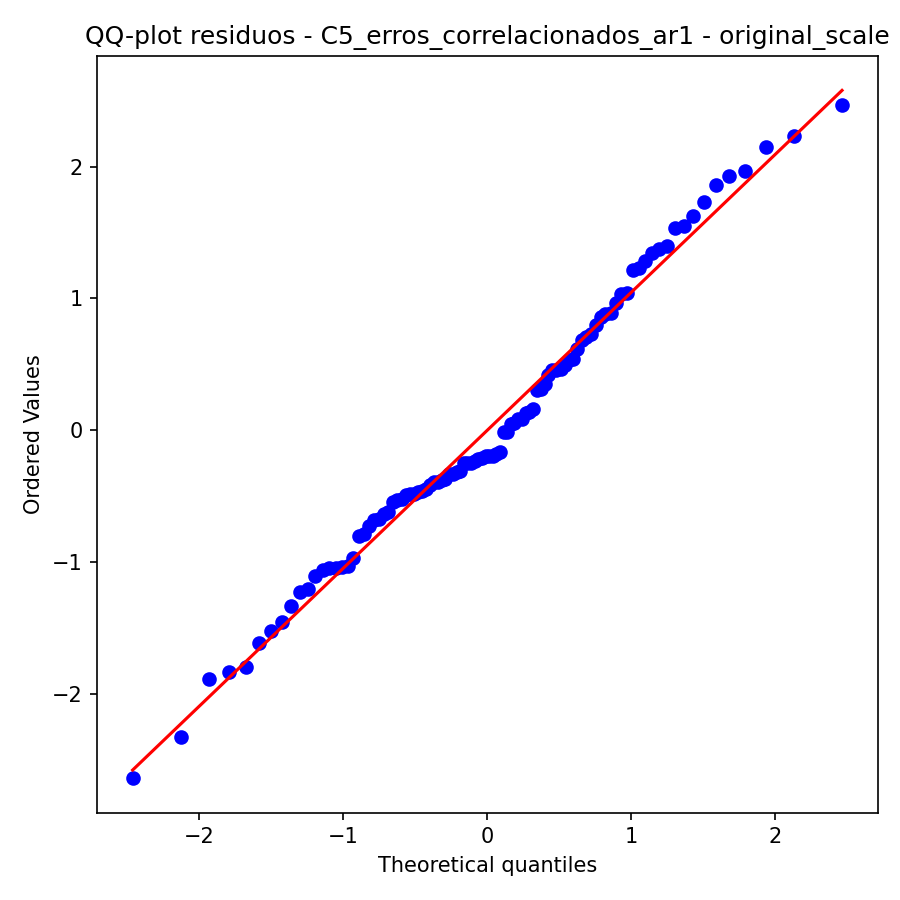

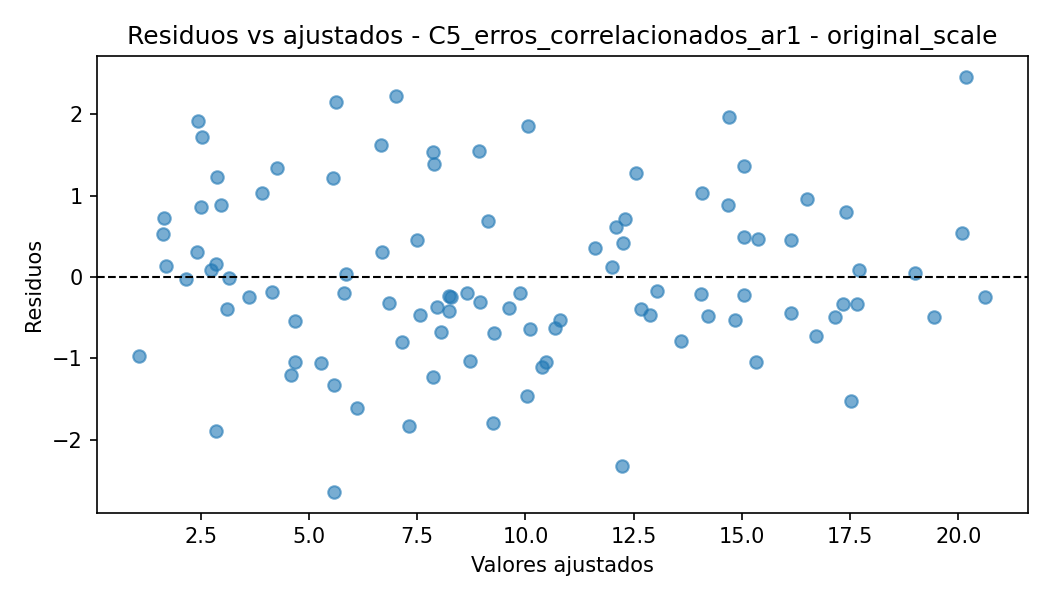

In [34]:
display(Image(filename=f'{output_dir}\\outputs\\figures\\C5_erros_correlacionados_ar1_n100_original_scale_qqplot_residuos.png'))
display(Image(filename=f'{output_dir}\\outputs\\figures\\C5_erros_correlacionados_ar1_n100_original_scale_residuos_vs_ajustados.png'))

## Cenário 6: Relação Exponencial e Transformação Logarítmica

Neste cenário, a relação entre as variáveis não é linear, mas sim exponencial: $Y_i = \exp(\beta_0 + \beta_1 X_i) \cdot \eta_i$, onde os erros são multiplicativos e seguem uma distribuição Lognormal. O objetivo é demonstrar a falha do MRLS na escala original e a eficácia da linearização do modelo através da aplicação do logaritmo natural em $Y$.

In [35]:
# Filtrando os resultados do Cenário 6 para as duas formas de ajuste
df_c6 = df_compact[df_compact["scenario_label"] == "C6_relacao_exponencial_lognormal"]

# Exibindo métricas de viés, variância e cobertura para os dois modelos
display(df_c6.sort_values(by=["n", "model", "parameter"])[["model", "n", "parameter", "bias", "variance", "mse", "coverage"]])

,model,n,parameter,bias,variance,mse,coverage
8,log_transform,30,beta0,-3.080652e-03,1.545938e-02,1.545341e-02,0.953
9,log_transform,30,beta1,1.215876e-04,6.546366e-04,6.539968e-04,0.961
10,original_scale,30,beta0,-6.751592e+07,2.855783e+14,4.843692e+15,1.000
11,original_scale,30,beta1,2.372677e+07,3.273563e+13,5.956625e+14,0.000
12,log_transform,100,beta0,3.814486e-04,8.540075e-03,8.531680e-03,0.939
13,log_transform,100,beta1,2.202896e-04,2.251917e-04,2.250151e-04,0.954
14,original_scale,100,beta0,-1.210159e+08,2.389243e+14,1.488354e+16,0.003
15,original_scale,100,beta1,3.993667e+07,2.390744e+13,1.618821e+15,0.000


### Impacto da Não-Linearidade (Escala Original)
- Vieses Gigantescos: O viés de $\beta_1$ em $n=30$ está na casa de $2.37 \times 10^7$. Isso ocorre porque uma reta tenta desesperadamente acompanhar uma curva exponencial, resultando em estimativas sem qualquer sentido físico ou estatístico.
- Cobertura Nula: A taxa de cobertura (coverage) é $0.000$. O modelo falha completamente em capturar o parâmetro real.

### A Eficácia da Transformação (Log-Transform)
- Recuperação da Precisão: O viés do $\beta_1$ cai de milhões para apenas $0.000121$ ($n=30$).
- Inferência Válida: A cobertura volta para os níveis ideais ($\approx 95\%$) e as variâncias tornam-se estáveis.
- Conclusão: Ao transformar $Y$ em $\log(Y)$, o modelo torna-se linear nos parâmetros ($log(Y_i) = \beta_0 + \beta_1 X_i + \epsilon_i$), permitindo que o MQO funcione com sua eficiência máxima.

### Diagnóstico Gráfico: O Poder da Transformação
- **Escala Original:** O gráfico de resíduos vs. ajustados apresentará um formato de "leque" ou "parábola" extremamente acentuado, indicando que a variância não é constante e a forma funcional está errada.
- **Escala Logarítmica:** Após a transformação, os resíduos devem se comportar como ruído branco (semelhante ao Cenário 1), com o QQ-plot alinhado à normalidade.

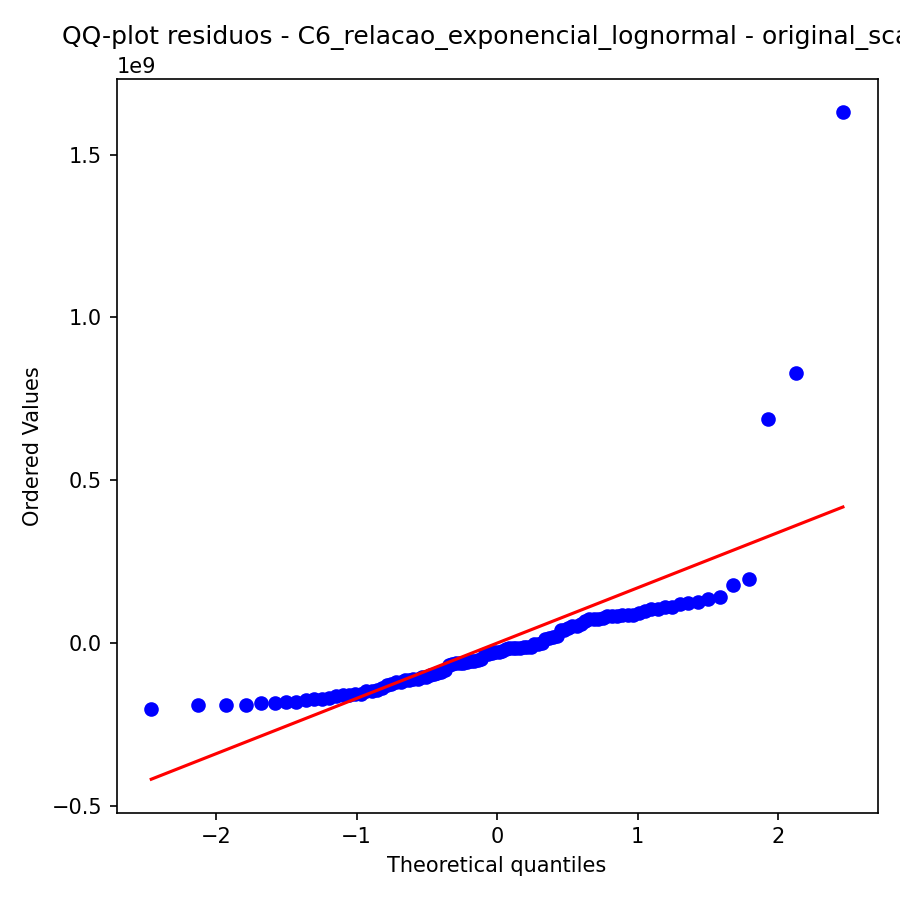

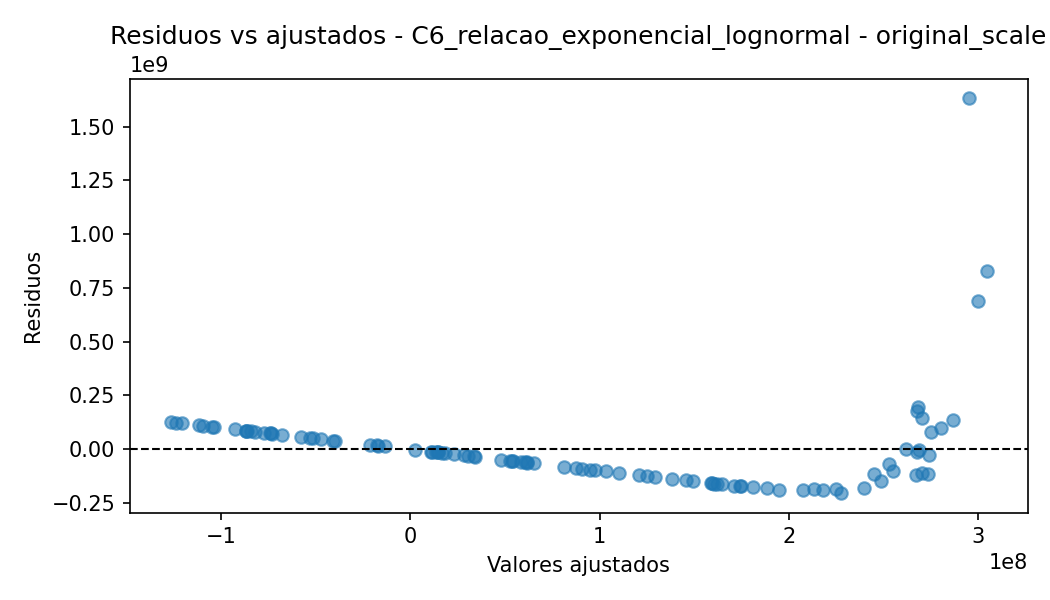

In [36]:
display(Image(filename=f'{output_dir}\\outputs\\figures\\C6_relacao_exponencial_lognormal_n100_original_scale_qqplot_residuos.png'))
display(Image(filename=f'{output_dir}\\outputs\\figures\\C6_relacao_exponencial_lognormal_n100_original_scale_residuos_vs_ajustados.png'))